**Previously on:** Lectures 19-21 fit lines (and, briefly, polynomials) -- every one of
those models was a straight sum of known basis terms (`x`, `x^2`, ...) with the
parameters entering as plain multipliers. Today the parameters stop entering that way.

Today's topics:
* writing a nonlinear model function (Lecture 14's pattern, one new rule)
* `scipy.optimize.curve_fit`, and why it needs a starting guess (`p0`) that `linregress`/
  `polyfit` never did
* consuming `popt`/`pcov` -- a point estimate and its uncertainty (Lecture 15's framing)
* one demo: `curve_fit` *is* `scipy.optimize.minimize` on squared error

> By the end of today you should be able to complete Problems 1-2 of Homework 8: fit a
> nonlinear model with `curve_fit` and read off its parameters, with uncertainty.

# Every model so far was secretly linear

A line `y = m*x + b`, a cubic `y = c3*x^3 + c2*x^2 + c1*x + c0` -- both are *linear
regression*: the parameters are plain multipliers on known functions of `x`. Today we fit
a model where that is no longer true, and Python will not care about the difference --
same goal, "minimize the sum of squared residuals," just a smarter search instead of a
closed-form formula.

# Loading and looking at a compression curve

## Dataset: Compression Test

Converted from `compression_test.xlsx` to `compression_test.csv` 2026-07-22
(cut-Excel decision; see `docs/2026-07-22-external-content-placement.md` #2) --
same two columns, same values, `pd.read_csv` in place of `pd.read_excel`. The
`.xlsx` file is kept on disk for historical reference only; do not read it from
any new code.

In [1]:
import os
import pandas as pd
import numpy as np

_file = 'compression_test.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# must reverse the axis because values were recorded as negative
data *= -1

# zero the initial point
data -= data.iloc[0, :]

data

,Position(Linear:Position) (in),Force(Linear:Load) (lb)
0,0.000000,0.000000
1,0.000128,0.349504
2,0.000170,0.450206
3,0.003805,10.724617
4,0.005040,14.439022
...,...,...
369,0.460608,3918.783335
370,0.461813,3959.527794
371,0.462997,4001.216560
372,0.464200,4045.137339


One 3D-printed part, loaded in compression on a testing machine; displacement and force,
already flipped positive and zeroed by the module.

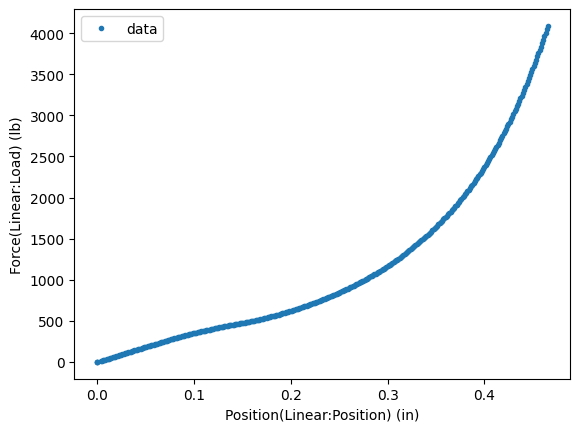

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_name, y_name = data.columns[0], data.columns[1]
x, y = data[x_name].to_numpy(), data[y_name].to_numpy()

fig, ax = plt.subplots()
ax.plot(x, y, '.', label='data')
ax.set_xlabel(x_name); ax.set_ylabel(y_name); ax.legend()
plt.show()

Not a straight line -- the slope itself keeps changing. Two regimes, by eye: an early,
gently-rising stretch (a **toe region** -- the part isn't yet in full, flat contact with
the platens, a well-known artifact in real compression tests, not a modeling mistake),
then a bend into a visibly steeper, stiffer stretch once contact is fully engaged -- the
local slope isn't perfectly smooth through that transition, but the two-regime read is
still the right first approximation. That second slope is the number we actually want:
the specimen's loading-region stiffness.

# A model function with a bend in it

Same pattern as Lecture 14: inputs in, a formula, a value out. The one new rule for
`curve_fit`: the *first* argument must be the independent variable, and every parameter
to be fit gets its own separate argument. Two straight lines, forced to meet with no jump
at a bend point `xb`:

$$
F(x) = \begin{cases} k_1\,x & x < x_b \\ k_1\,x_b + k_2\,(x - x_b) & x \ge x_b \end{cases}
$$

In [3]:
def bilinear_stiffness(x, k1, xb, k2):
    """Two-segment stiffness model: toe stiffness k1 up to the bend xb, then loading
    stiffness k2 beyond it.
    k1 : toe (initial-contact) stiffness, lb/in
    xb : bend point -- displacement where full contact is reached, in
    k2 : loading-region stiffness ("the modulus" we report), lb/in
    """
    Fb = k1 * xb  # continuity at the bend -- no jump in force
    return np.where(x < xb, k1 * x, Fb + k2 * (x - xb))

# Fitting with `curve_fit`

Same idea as `linregress` -- minimize the sum of squared residuals -- but no closed-form
formula exists for a bent function like this, so `curve_fit` searches numerically instead.
That search needs a **starting guess**, `p0`, in roughly the right ballpark:

In [4]:
from scipy import optimize

p0 = [4000, 0.3, 15000]  # rough by-eye read of the two slopes and where the bend looks to be
popt, pcov = optimize.curve_fit(bilinear_stiffness, x, y, p0=p0)
print(popt)

[3.55544401e+03 3.28407946e-01 1.89181675e+04]


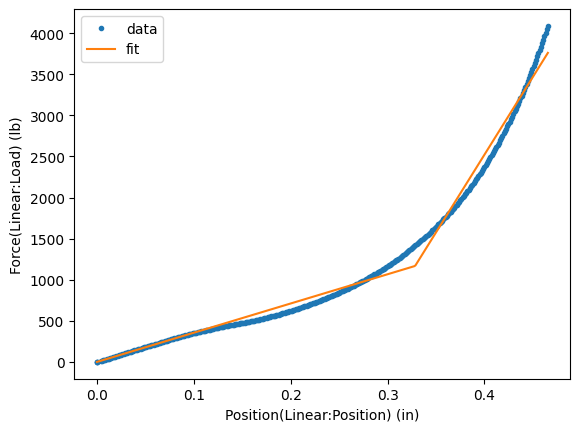

In [5]:
fig, ax = plt.subplots()
ax.plot(x, y, '.', label='data')
ax.plot(x, bilinear_stiffness(x, *popt), '-', color='C1', label='fit')
ax.set_xlabel(x_name); ax.set_ylabel(y_name); ax.legend()
plt.show()

`k1_fit, xb_fit, k2_fit = popt` -- read the loading-region stiffness (`k2`) off directly.
This is the number Homework 8 wants you able to extract from *any* nonlinear fit, not
just this one.

**`p0` is not optional decoration.** Call `curve_fit` with no `p0` at all -- it silently
defaults every parameter to `1` -- and watch what happens:

no p0: [5.3766756e+03 1.0000000e+00 1.0000000e+00]


/var/folders/gp/17x29r6s3l7dzdvpf785tzw40000gn/T/ipykernel_81865/1346600492.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_nop0, _ = optimize.curve_fit(bilinear_stiffness, x, y)


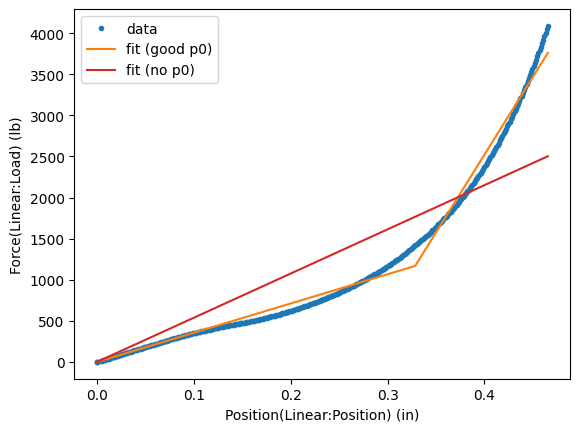

In [6]:
popt_nop0, _ = optimize.curve_fit(bilinear_stiffness, x, y)
print('no p0:', popt_nop0)

fig, ax = plt.subplots()
ax.plot(x, y, '.', label='data')
ax.plot(x, bilinear_stiffness(x, *popt), '-', color='C1', label='fit (good p0)')
ax.plot(x, bilinear_stiffness(x, *popt_nop0), '-', color='C3', label='fit (no p0)')
ax.set_xlabel(x_name); ax.set_ylabel(y_name); ax.legend()
plt.show()

No error, no crash -- `curve_fit` reports success and hands back a bend point (`xb ≈ 1`)
nowhere near the data (`x` only goes up to about 0.47). A bad `p0` doesn't always fail
loudly; sometimes it just quietly lands on the wrong answer. Always sanity-check a fit by
plotting it over the data, every time.

# Is the fit good? R² and RMSE, same vocabulary as L19-20

In [7]:
y_fit = bilinear_stiffness(x, *popt)
resid = y - y_fit
rmse = np.sqrt(np.mean(resid**2))
r2 = 1 - np.var(resid) / np.var(y - y.mean())
print(f'RMSE = {rmse:.1f}, R2 = {r2:.4f}')

RMSE = 92.5, R2 = 0.9917


R² ≈ 0.99, RMSE small relative to the force scale -- a strong fit, and reused vocabulary,
not new math: L20 promised `evaluate_model`'s R²/RMSE habit would apply to every model the
rest of this module, nonlinear fitting included. One honest wrinkle: residuals are
elevated through roughly `x` ≈ 0.14-0.37 (the transition into full contact isn't perfectly
sharp) and largest at the very end of the curve (near maximum displacement), where the
part may be starting to densify -- neither is a regime the two-segment model was ever
asked to cover. A good R² describes the regime the model targets, not a universal verdict
on the whole curve.

# Consuming the result: `popt` and `pcov`

Direct callback to Lecture 15: `curve_fit` hands back a tuple of two arrays. We don't need
to know how it computed them, just what each one *means*.

* `popt` -- the point estimate, already used above.
* `pcov` -- the covariance matrix. `sqrt(diag(pcov))` turns it into a 1-sigma uncertainty
  on each parameter:

In [8]:
perr = np.sqrt(np.diag(pcov))
for name, val, err in zip(['k1', 'xb', 'k2'], popt, perr):
    print(f'{name} = {val:.3g} +/- {err:.2g}')

k1 = 3.56e+03 +/- 30
xb = 0.328 +/- 0.0013
k2 = 1.89e+04 +/- 2.2e+02


`curve_fit` doesn't just give a best answer, it gives a confidence interval on that answer
for free -- the difference between reporting `k2 = 18918` and `k2 = 18918 +/- 221`, and
the second one is what belongs in a lab report.

# `curve_fit` *is* `minimize`

`curve_fit` is not magic -- it calls the same general-purpose optimizer you'd reach for if
you built this yourself. Define the sum-of-squared-error objective by hand, reusing
`bilinear_stiffness`, and minimize it directly:

In [9]:
from scipy.optimize import minimize

def sse(params):
    k1, xb, k2 = params
    return np.sum((bilinear_stiffness(x, k1, xb, k2) - y) ** 2)

result = minimize(sse, x0=p0, method='Nelder-Mead')
print(result.x)   # compare to popt below
print(popt)

[3.56398634e+03 3.29171902e-01 1.90158846e+04]
[3.55544401e+03 3.28407946e-01 1.89181675e+04]


Matching answers, up to solver tolerance. **`curve_fit(model, x, y, p0=...)` is shorthand
for `minimize(sum-of-squared-residuals, x0=p0)`.** `curve_fit` is the specialized tool for
exactly this job; `minimize` is the general-purpose tool underneath it, and underneath
every model-fitting function this module has used.

## [Check your understanding]

Refit with a different, still-reasonable starting guess: `p0=[1000, 0.3, 8000]`. Does
`curve_fit` converge to the same `popt` as Section 4's fit? Print both and compare. Then
explain in one sentence why this guess worked while the no-`p0` case above did not --
what does a "reasonable" `p0` need to get right that a default of all-ones doesn't?

# Wrap-up

* A nonlinear model function: first argument is `x`, every fit parameter gets its own
  argument.
* `p0` is a required starting guess for `curve_fit` -- unlike `linregress`/`polyfit`, and
  the one genuinely new risk of nonlinear fitting: a bad guess can converge to nonsense
  with no error at all.
* `popt`/`pcov` are a point estimate and its uncertainty -- consumed, not derived by hand.
* `curve_fit` is `minimize` on squared error, specialized for this exact job.

**Take-home message:** every fit this module -- `linregress`, `lstsq`, `curve_fit` -- has
been "minimize squared error," just with a different search strategy depending on whether
the model is linear in its parameters; always plot a fit over its data before trusting it.

Next class: Lecture 23 moves from one input to many -- multivariate regression, predicting
a 3D-printed part's strength from several process settings at once. Homework 8 repeats
today's exact `curve_fit` workflow on two new equations (Arrhenius, power-law hardening),
plus a third nonlinear shape.